# **Deep Learning - Conception d’un Agent IA Tuteur et d’une IA Apprenante**
Arthur Péraud, Pierre Beauvain, Nice Prado, Ayoub Achour


## **Sommaire**
- **Partie 1 - Architecture de l'IA Tuteur**
- **Partie 2 - Conception de l'IA Apprenante**


## **Partie 1 - Architecture de l'IA Tuteur**
-----

### Objectif
- Assister les développeurs Python/ML
- Répondre sur : scikit-learn, TensorFlow, PyTorch
- Modes : sans RAG (généraliste), avec RAG (basé docs)

### Composants
- **LLM** : Ollama (llama2 local)
- **Embeddings** : nomic-embed-text (Ollama)
- **VectorStore** : Chroma
- **Document loaders** : TextLoader, PyPDFLoader, UnstructuredHTMLLoader

### Pipeline RAG
- Charger docs (txt/pdf/html) → Splitter (800 chunks) → Embeddings → Chroma
- Query → Retriever → Prompt augmenté → LLM → Réponse

### Base documentaire
- Documentation officielle scikit-learn/TensorFlow/PyTorch
- Slides Cours Deep Learning

### Analyse des réponses
- Relevance : cite-t-elle les docs ?
- Accuracy : compare avec réponses sans RAG
- Metrics : latence, qualité pédagogique etc

In [280]:
import requests, json, os

try:
    from langchain_community.document_loaders import (
        TextLoader,
        PyPDFLoader,
        UnstructuredHTMLLoader,
        NotebookLoader,
        UnstructuredMarkdownLoader,
        UnstructuredRSTLoader,
    )
    from langchain_text_splitters import RecursiveCharacterTextSplitter
    from langchain_ollama import OllamaEmbeddings
    from langchain_chroma import Chroma
    import matplotlib.pyplot as plt
    import tensorflow.keras.layers as layers
except ImportError as e:
    print("Installer les packages : pip install langchain langchain-ollama langchain-chroma langchain-community chromadb pypdf unstructured langchain-text-splitters")

os.system("curl http://localhost:11434/")

Ollama is running

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0   3667      0 --:--:-- --:--:-- --:--:--  4250


0

# Configuration d'Ollama

In [227]:
### Config Ollama ###

LANGUAGE = "EN"  # EN ou FR
# Ressources du rag seront en anglais

OLLAMA_URL = "http://localhost:11434"

# Modèle
TUTOR_MODEL = "llama2" # ou "deepseek-coder"  

# Paramètres LLM
LLM_TOP_P = 0.9
LLM_MIN_P = 0.0
LLM_TOP_K = 40
LLM_TEMP = 0
LLM_MAX_TOKEN = 2048
SEED = 0

# RAG Config
EMBED_MODEL = "nomic-embed-text"
CHROMA_DIR = "./chroma_db_tuteur"

# PROMPTS 

SYSTEM_TUTEUR_PYTHON_FR = """
Tu es un tuteur IA spécialisé en Python et en apprentissage automatique/profond.
Tu maîtrises particulièrement : scikit-learn, TensorFlow et PyTorch, ainsi que numpy et pandas.

Ta mission :
- Expliquer du code Python.
- Aider à corriger des erreurs (en analysant code + message d'erreur).
- Proposer des améliorations (performance, style, bonnes pratiques).
- Proposer une documentation (docstrings, commentaires, type hints).

Règles :
- Réponds en français.
- Donne des exemples de code clairs et complets si utile.
- Sois pédagogique et structuré.
- Ne répète jamais plusieurs fois la même ligne de code ou le même commentaire.
"""

SYSTEM_TUTEUR_PYTHON_EN = """
You are an AI tutor specialized in Python and machine / deep learning.
You are especially proficient with: scikit-learn, TensorFlow, PyTorch, as well as NumPy and pandas.

Your role:
- Explain Python code.
- Help debug errors (by analyzing code and error messages).
- Propose improvements (performance, style, best practices).
- Propose documentation (docstrings, comments, type hints).

Rules:
- Always answer in clear, fluent English only (no other language characters).
- Provide clear and complete code examples when useful.
- Be pedagogical and well structured.
- Never repeat the same line of code or the same comment multiple times.
"""

SYSTEM_TUTEUR_PYTHON = SYSTEM_TUTEUR_PYTHON_EN if LANGUAGE == "EN" else SYSTEM_TUTEUR_PYTHON_FR

In [228]:
def test_ollama():
    """Vérifie que le serveur Ollama répond."""
    try:
        r = requests.get(f"{OLLAMA_URL}/api/version")
        r.raise_for_status()
        print(f"[OK] Ollama version: {r.json()['version']}")
    except Exception as e:
        print(f"[KO] Impossible de contacter Ollama: {e}")
        raise

def call_ollama_raw_generate(
    prompt: str,
    model: str = TUTOR_MODEL,
    temperature: float = LLM_TEMP,
    max_tokens: int = LLM_MAX_TOKEN,
    top_p: float = LLM_TOP_P,
    min_p: float = LLM_MIN_P,
    top_k: int = LLM_TOP_K,
    seed: int = SEED,
    stream: bool = False,
):
    """Appel bas niveau à /api/generate avec paramètres."""
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": stream,
        "options": {
            "temperature": temperature,
            "top_p": top_p,
            "top_k": top_k,
            "min_p": min_p,
            "seed": seed,
            "num_predict": max_tokens,
            "repeat_penalty": 1.1,
            "presence_penalty": 0.0,
            "frequency_penalty": 0.0,
        },
    }

    r = requests.post(f"{OLLAMA_URL}/api/generate", json=payload, stream=stream)
    r.raise_for_status()
    
    if stream:
        # Streaming
        full_response = ""
        for line in r.iter_lines():
            if line:
                chunk = json.loads(line)
                if "response" in chunk:
                    print(chunk["response"], end="", flush=True)
                    full_response += chunk["response"]
                if chunk.get("done"):
                    print()
                    break
        return {"response": full_response.strip()}
    else:
        # Non-streaming
        return r.json()


def call_ollama_simple(prompt: str, model: str = TUTOR_MODEL, stream : bool = False) -> str:
    """Version simple: renvoie juste le champ 'response'."""
    data = call_ollama_raw_generate(prompt, model = model, stream = stream)
    return data["response"]

In [229]:
test_ollama()

[OK] Ollama version: 0.12.4


In [230]:
def check_load_models():
    """Vérifie si les modèles ont déjà été chargés sinon ils le sont"""
    flag_embed = False
    flag_tutor = False
    r = requests.get(f"{OLLAMA_URL}/api/tags")
    r.raise_for_status()
    for e in r.json()["models"]:
        
        flag_embed |= EMBED_MODEL in e["name"]
        flag_tutor |= TUTOR_MODEL in e["name"]
        if flag_tutor and flag_embed:
            return None
    if not flag_embed:
        print(f'Loading {EMBED_MODEL}...')
        requests.post(
		    f"""{OLLAMA_URL}/api/pull""", 
		    json={'name':EMBED_MODEL}
	    )
        print("Done.")

    if not flag_tutor:
        print(f'Loading {TUTOR_MODEL}...')
        requests.post(
		    f"""{OLLAMA_URL}/api/pull""", 
		    json={'name':TUTOR_MODEL}
	    )
        print("Done.")
    return None

In [231]:
check_load_models()

---
# Base Documentaire

In [232]:
def load_single_file(path: str):
    """
    Charge un fichier en fonction de son extension.
    (.txt, .pdf, .html/.htm, .ipynb, .md, .rst)
    """
    ext = os.path.splitext(path)[1].lower()
    try:
        if ext == ".txt":
            loader = TextLoader(path, encoding="utf-8")

        elif ext == ".pdf":
            loader = PyPDFLoader(path)

        elif ext in [".html", ".htm"]:
            loader = UnstructuredHTMLLoader(path)

        elif ext == ".ipynb":
            loader = NotebookLoader(
                path,
                include_outputs=False,
                max_output_length=100,
                remove_newline=True,
            )

        elif ext == ".md":
            loader = UnstructuredMarkdownLoader(
                path,
                mode="single",
                strategy="fast",
            )

        elif ext == ".rst":
            loader = UnstructuredRSTLoader(
                path,
                mode="single",
            )

        else:
            print(f"[SKIP] Extension inconnue {ext}: {path}")
            return []

        docs = loader.load()
        print(f"{path} : {len(docs)} docs")
        return docs
        
    except Exception as e:
        print(f"Skipped Erreur {path}: {str(e)[:50]}...")
        return []

def load_documents_from_folder(folder_path: str):
    """
    Charge tous les fichiers supportés dans un dossier.
    """
    docs = []
    for root, _, files in os.walk(folder_path):
        for fname in files:
            if fname.lower().endswith((".txt", ".pdf", ".html", ".htm", ".ipynb", ".md", ".rst")):
                
                full_path = os.path.join(root, fname)
                print(f"Loading {full_path}")
                docs.extend(load_single_file(full_path))
    return docs

def build_vectorstore_from_folder(folder_path: str, persist_directory: str = CHROMA_DIR):
    """
    Charge les docs, les découpe en chunks et construit la base Chroma.
    """
    print("Chargement des fichiers...")
    docs = load_documents_from_folder(folder_path)
    if not docs:
        raise RuntimeError("Aucun document trouvé dans le dossier.")

    print(f"{len(docs)} documents chargés. Découpage en chunks...")
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=800,
        chunk_overlap=100,
    )
    chunks = splitter.split_documents(docs)
    print(f"{len(chunks)} chunks obtenus.")

    print("Initialisation embeddings Ollama...")
    embeddings = OllamaEmbeddings(model=EMBED_MODEL)

    print("Construction de la base Chroma...")
    vectorstore = Chroma.from_documents(
        chunks,
        embedding=embeddings,
        persist_directory=persist_directory,
    )
    print("Base Chroma construite.")
    return vectorstore

def load_vectorstore(persist_directory: str = CHROMA_DIR):
    """
    Recharge une base Chroma existante depuis le disque.
    """
    embeddings = OllamaEmbeddings(model=EMBED_MODEL)
    vectorstore = Chroma(
        embedding_function=embeddings,
        persist_directory=persist_directory,
    )
    return vectorstore

def reset_vectorstore(persist_directory: str = CHROMA_DIR):
    """Supprime et réinitialise la base vectorielle."""
    import glob, shutil
    
    # Supprime tout
    for chroma_dir in glob.glob(f"{persist_directory}*"):
        print(f"Supprime {chroma_dir}")
        shutil.rmtree(chroma_dir, ignore_errors=True)
    
    os.makedirs(persist_directory, exist_ok=True)
    print(f"{persist_directory} prêt")

In [233]:
#reset_vectorstore()

In [277]:
# Charger corpus doc
#import chromadb
#chromadb.api.client.SharedSystemClient.clear_system_cache()
#build_vectorstore_from_folder("./docs_corpus")

In [235]:
vectorstore = load_vectorstore("./chroma_db_tuteur/")

# Test 
question = "What is a Random Forest using scikit-learn and give us an example"
docs = vectorstore.similarity_search(question, k=10)
for d in docs: print(d.metadata)

{'source': './docs_corpus/libs/sklearn/modules/ensemble.html'}
{'source': './docs_corpus/libs/sklearn/getting_started.html'}
{'source': './docs_corpus/libs/sklearn/_sources/modules/ensemble.rst.txt'}
{'source': './docs_corpus/libs/sklearn/modules/generated/sklearn.ensemble.RandomForestClassifier.html'}
{'source': './docs_corpus/libs/sklearn/auto_examples/ensemble/plot_ensemble_oob.html'}
{'source': './docs_corpus/libs/sklearn/modules/generated/sklearn.ensemble.RandomForestRegressor.html'}
{'source': './docs_corpus/libs/sklearn/auto_examples/ensemble/plot_random_forest_regression_multioutput.html'}
{'source': './docs_corpus/libs/sklearn/modules/ensemble.html'}
{'source': './docs_corpus/libs/sklearn/auto_examples/ensemble/plot_forest_hist_grad_boosting_comparison.html'}
{'source': './docs_corpus/libs/sklearn/modules/generated/sklearn.ensemble.RandomForestClassifier.html'}


----
# Conception Tuteur NoRag / Rag

In [236]:
def Tutor_python(question: str, model: str = TUTOR_MODEL, stream: bool = False) -> str:
    """Tuteur Python/ML sans RAG."""
    system_prompt = SYSTEM_TUTEUR_PYTHON
    
    prompt = f"""{system_prompt}
        Question:
        {question}
    """
    
    return call_ollama_simple(prompt, model=model, stream=stream)

In [237]:
def Tutor_python_rag(question: str, vectorstore, model: str = TUTOR_MODEL, k: int = 4, max_chunk_display: int = 250, stream: bool = False) -> tuple[str, list[dict]]:
    """
    Tuteur Python/ML AVEC RAG :
    Retourne (réponse, sources)
    """
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    docs = retriever.invoke(question)
    
    sources = []
    context_parts = []
    
    for i, d in enumerate(docs):
        source_info = {
            "index": i+1,
            "source": d.metadata.get("source", f"doc_{i}"),
            "framework": d.metadata.get("framework", "unknown"),
            "content_preview": d.page_content[:100] + "..." if len(d.page_content) > 100 else d.page_content,
            "full_length": len(d.page_content)
        }
        sources.append(source_info)
        
        # Pour le contexte (tronqué)
        content = d.page_content
        if len(content) > max_chunk_display:
            content = content[:max_chunk_display]
        context_parts.append(f"[Source {i+1}: {source_info['source']}]\n{content}")
    
    context = "\n\n---\n\n".join(context_parts)
    
    promptfr = (
        f"{SYSTEM_TUTEUR_PYTHON}\n\n"
        "Contexte documentaire (extraits de la base locale Python/ML) :\n"
        f"{context}\n\n"
        "En t'appuyant en priorité sur ce contexte, réponds à la question suivante.\n\n"
        "Question de l'utilisateur :\n"
        f"{question}\n\n"
        "Réponse détaillée du tuteur IA :"
    )
    
    prompt_en = (
        f"{SYSTEM_TUTEUR_PYTHON_EN}\n\n"
        "Document context (excerpts from the local Python/ML knowledge base):\n"
        f"{context}\n\n"
        "Using this context as your main source, answer the following question.\n\n"
        "User question:\n"
        f"{question}\n\n"
        "Detailed answer of the AI tutor:"
    )
    
    if LANGUAGE == "EN": 
        prompt = prompt_en
    else: 
        prompt = promptfr
    
    response = call_ollama_simple(prompt, model=model, stream=stream)
    return response, sources

In [238]:
ques = "What is an autoencoder and how de we denoise it ? Give a Code Example"

### No Rag

In [239]:
rep_norag = Tutor_python(ques, stream=True)

Of course! I'd be happy to help you with your question on autoencoders and denoising.

An autoencoder is a type of neural network that is trained to reconstruct its input. In other words, the network learns to compress the input data into a smaller representation, called the bottleneck or latent representation, and then reconstruct the original input from this representation. Autoencoders are often used for dimensionality reduction, anomaly detection, and denoising tasks.

To denoise an image using an autoencoder, you can train the network on a dataset of clean images and then use it to denoise new images that have noise added to them. The idea is that the autoencoder will learn to reconstruct the clean image from the noisy input, resulting in a denoised output.

Here's an example code for training an autoencoder using Keras, a popular deep learning library for Python:
```python
# Import necessary libraries
from keras.models import Sequential
from keras.layers import Dense, Dropout, Ac

### Rag 

In [240]:
rep_rag, sources = Tutor_python_rag(ques, vectorstore, stream=True)

Hello there! As an AI tutor specialized in Python and machine learning, I'd be happy to help you understand what an autoencoder is and how to denoise it.

An autoencoder is a type of neural network that is trained to copy its input to its output. In other words, the goal of an autoencoder is to reconstruct its input from its output. This is done by learning a compact representation of the input data, which can be useful for tasks such as image denoising, anomaly detection, and dimensionality reduction.

To denoise an autoencoder, we need to modify the network architecture or the training process. Here are some possible ways to do it:

1. Regularization techniques: One way to denoise an autoencoder is to add regularization terms to the loss function during training. For example, you can add a L1 or L2 regularization term to the loss function to penalize large weights and prevent overfitting.
```python
loss = losses.MeanSquaredError() + alpha * losses.L1Regularization()
autoencoder.compi

# Méthodologie d'Évaluation (Benchmark)

Pour valider l'efficacité de notre RAG, nous avons développé un benchmark automatisé comparant le mode **"Non-RAG"** (connaissances brutes du modèle) vs **"RAG"** (assisté par documentation).

### Métriques Surveillées :
*   **Performance** : Latence (temps de réponse) et longueur de la réponse.
*   **Preuve d'utilisation (Chroma Proofs)** :
    *   *ML Specificity* : % de termes techniques des sources retrouvés dans la réponse.
    *   *Fingerprint* : Empreinte lexicale spécifique aux documents sources.
*   **Qualité Pédagogique** : Score composite évaluant la structure, la présence de code, et la clarté.


In [241]:
### BENCHMARK RAG vs NON-RAG
import time
import re
from typing import Dict, List
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [242]:
### Fonctions test utilisations de chroma ?

def calculate_lexical_overlap(text1: str, text2: str, exclude_common: bool = True) -> float:
    """Jaccard similarity between two texts."""
    common_words = {
        'the', 'and', 'for', 'with', 'use', 'code', 'model', 'data',
        'is', 'are', 'to', 'in', 'of', 'a', 'an', 'that', 'this',
        'on', 'it', 'be', 'as', 'by', 'or', 'from', 'at', 'which',
        'have', 'has', 'can', 'will', 'should', 'would', 'could', 'may'
    }
    
    words1 = set(re.findall(r'\w+', text1.lower()))
    words2 = set(re.findall(r'\w+', text2.lower()))
    
    if exclude_common:
        words1 -= common_words
        words2 -= common_words
    
    if len(words1 | words2) == 0:
        return 0.0
    
    return len(words1 & words2) / len(words1 | words2)

def chroma_fingerprint(response: str, sources_info: List[Dict]) -> float:
    """Measures % of RARE words from sources found in response."""
    if not sources_info: return 0.0
    
    valid_sources = [s for s in sources_info if isinstance(s, dict)]
    if not valid_sources: return 0.0
    
    all_source_text = " ".join([
        s.get('content_preview', '') or s.get('full_content', '') or ''
        for s in valid_sources
    ]).lower()
    
    source_terms = set(re.findall(r'\b\w{4,}\b', all_source_text))
    generic = {'that', 'this', 'with', 'from', 'have', 'which', 'their', 'would', 'more', 'about', 'used', 'such', 'when', 'where', 'being', 'also', 'your', 'will', 'does', 'should', 'could', 'might', 'must', 'only'}
    source_terms -= generic
    
    if not source_terms: return 0.0
    
    response_words = set(re.findall(r'\b\w{4,}\b', response.lower()))
    rare_overlap = len(source_terms & response_words)
    
    return min(rare_overlap / len(source_terms), 1.0)

def ml_specificity_score(response: str, sources_info: List[Dict]) -> float:
    """Measures technical ML terms coverage."""
    if not sources_info: return 0.0
    
    valid_sources = [s for s in sources_info if isinstance(s, dict)]
    if not valid_sources: return 0.0
    
    source_text = " ".join([
        s.get('content_preview', '') or s.get('full_content', '') or ''
        for s in valid_sources
    ]).lower()
    
    ml_terms = {
        'pytorch': ['torch', 'nn.', 'device', 'cuda', 'backward', 'optimizer', 'dataloader', 'tensor', 'conv2d', 'linear', 'relu', 'batchnorm', 'dropout', 'crossentropyloss', 'adam', 'sgd', 'requires_grad'],
        'sklearn': ['sklearn', 'pipeline', 'gridsearchcv', 'standardscaler', 'minmaxscaler', 'train_test_split', 'cross_val_score', 'randomforest', 'svm', 'knn', 'logisticregression', 'fit', 'predict', 'transform', 'fit_transform'],
        'tensorflow': ['tensorflow', 'tf.', 'keras', 'model', 'sequential', 'dense', 'conv2d', 'maxpooling', 'flatten', 'dropout', 'batchnormalization', 'adam', 'rmsprop', 'sparse_categorical_crossentropy', 'categorical_crossentropy', 'accuracy', 'epoch']
    }
    
    source_terms_found = set()
    for framework, terms in ml_terms.items():
        for term in terms:
            if term.lower() in source_text:
                source_terms_found.add(term.lower())
    
    if not source_terms_found: return 0.0
    
    response_lower = response.lower()
    response_terms_found = sum(1 for term in source_terms_found if term in response_lower)
    
    return min(response_terms_found / len(source_terms_found), 1.0)

def semantic_consistency_score(response: str, sources_info: List[Dict]) -> float:
    """Measures logical/semantic alignment."""
    if not sources_info: return 0.5
    
    valid_sources = [s for s in sources_info if isinstance(s, dict)]
    if not valid_sources: return 0.5
    
    source_text = " ".join([
        s.get('content_preview', '') or s.get('full_content', '') or ''
        for s in valid_sources
    ]).lower()
    
    response_sentences = re.split(r'[.!?]+', response.lower())
    source_sentences = re.split(r'[.!?]+', source_text)
    
    matched_sentences = 0
    for r_sent in response_sentences:
        if len(r_sent.strip()) < 15: continue
        for s_sent in source_sentences:
            overlap = calculate_lexical_overlap(r_sent, s_sent, exclude_common=False)
            if overlap > 0.5:
                matched_sentences += 1
                break
    
    valid_response_sents = len([s for s in response_sentences if len(s.strip()) > 15])
    sentence_match = matched_sentences / max(valid_response_sents, 1)
    
    # Correction du bug len(int) ici aussi au cas où
    source_lengths = [s.get('full_length', 500) for s in valid_sources]
    avg_source_len = np.mean(source_lengths) if source_lengths else 500
    
    response_len = len(response)
    length_ratio = min(response_len / (avg_source_len * len(valid_sources)), 2.0)
    
    consistency = (sentence_match * 0.6) + (min(length_ratio / 2, 1.0) * 0.4)
    return min(consistency, 1.0)

In [243]:
### Différentes métriques

def score_pedagogical_value(response: str) -> float:
    """Score (0-1): structure, code examples, clarity."""
    score = 0.0
    # Code examples
    if re.search(r'(```|def |import |class |\.fit\(|\.predict|=>|lambda)', response, re.IGNORECASE):
        score += 0.3
    # Structure (lists, bullets, numbering)
    if re.search(r'^\s*[\d+\-\*][\.\)]\s', response, re.MULTILINE):
        score += 0.25
    # Logical explanation
    if re.search(r'\b(because|therefore|thus|hence|so|as a result|consequently)\b', response, re.IGNORECASE):
        score += 0.25
    # Explicit examples
    if re.search(r'\b(example|for instance|e\.g\.|such as|like|demonstrate)\b', response, re.IGNORECASE):
        score += 0.2
    return min(score, 1.0)

def response_diversity(response: str) -> float:
    """Vocabulary Diversity: Type-Token Ratio."""
    words = re.findall(r'\w+', response.lower())
    if not words: return 0.0
    unique_words = len(set(words))
    return unique_words / len(words)

def response_conciseness(response: str) -> float:
    """Conciseness: penalize overly verbose responses."""
    length = len(response)
    optimal_min, optimal_max = 300, 800
    if length < optimal_min:
        return length / optimal_min
    elif length > optimal_max:
        return min(1.0, optimal_max / length)
    else:
        return 1.0

In [244]:
### BENCHMARK

class TutorBenchmark:
    """
    RAG vs Non-RAG benchmark
    """
    
    def __init__(self, vectorstore=None, default_model: str = TUTOR_MODEL):
        self.vectorstore = vectorstore
        self.default_model = default_model
        self.results = []
    
    def test_single_question(
        self,
        question: str,
        model : str,
        use_rag: bool = True,
        k_retrieval: int = 4,
        stream: bool = False
    ) -> Dict:
        """
        Test a single question with specific model passed directly to Tutor functions
        """
        
        start_time = time.time()
        sources_info = []
        
        try:
            if use_rag and self.vectorstore:
                # Rag
                response, sources_info = Tutor_python_rag(
                    question=question,
                    vectorstore=self.vectorstore,
                    k=k_retrieval,
                    stream=stream,
                    model=model
                )
            else:
                # NoRag
                response = Tutor_python(
                    question=question, 
                    stream=stream,
                    model=model
                )
        except Exception as e:
            print(f"Error with model {model}: {e}")
            response = "Error generation"
            latency = 0
        
        latency = time.time() - start_time
        
        # 1. CHROMA PROOFS (RAG)
        fingerprint = chroma_fingerprint(response, sources_info) if use_rag else 0.0
        specificity = ml_specificity_score(response, sources_info) if use_rag else 0.0
        consistency = semantic_consistency_score(response, sources_info) if use_rag else 0.0
        chroma_confidence = (fingerprint + specificity + consistency) / 3 if use_rag else 0.0
        
        # 2. QUALITY METRICS
        pedagogical = score_pedagogical_value(response)
        diversity = response_diversity(response)
        conciseness = response_conciseness(response)
        
        # 3. SIZE METRICS
        response_tokens = len(response) / 4
        response_words = len(response.split())
        
        result = {
            "question": question,
            "mode": "RAG" if use_rag else "Non-RAG",
            "model": model,
            "k_retrieval": k_retrieval if use_rag else None,
            "num_sources_retrieved": len(sources_info) if use_rag else 0,
            
            "latency_seconds": latency,
            "response_length_chars": len(response),
            "response_tokens": response_tokens,
            "response_words": response_words,
            
            "fingerprint_score": fingerprint,
            "ml_specificity_score": specificity,
            "semantic_consistency_score": consistency,
            "chroma_confidence": chroma_confidence,
            
            "pedagogical_score": pedagogical,
            "vocabulary_diversity": diversity,
            "conciseness_score": conciseness,
            
            "response_preview": response[:400],
            "sources_info": sources_info,
        }
        
        self.results.append(result)
        return result
    
    def benchmark_questions(
        self,
        questions: List[str],
        compare_rag_vs_non_rag: bool = True,
        k_values: List[int] = [1, 4],
        stream: bool = False,
        verbose: bool = True
    ):
        
        model = self.default_model
        
        if verbose:
            print(f"\n{'-'*100}")
            print(f"Benchmark: {len(questions)} questions | Model: {model}")
        
        for i, question in enumerate(questions, 1):
            if verbose:
                print(f"[{i}/{len(questions)}] Q: {question[:80]}...")
            
            if compare_rag_vs_non_rag:
                if verbose: print(f"    > Non-RAG ({model})...")
                self.test_single_question(question, use_rag=False, stream=stream, model=model)
                
                for k in k_values:
                    if verbose: print(f"    > RAG k={k} ({model})...")
                    self.test_single_question(question, use_rag=True, k_retrieval=k, stream=stream, model=model)
            else:
                for k in k_values:
                    if verbose: print(f"    > RAG k={k} ({model})...")
                    self.test_single_question(question, use_rag=True, k_retrieval=k, stream=stream, model=model)
            
            if verbose: print()

    def get_results_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.results)

In [245]:
def create_detailed_comparison_table(results: List[Dict]) -> pd.DataFrame:
    """
    Detailed comparison table: RAG vs Non-RAG
    """
    df = pd.DataFrame(results)
    
    summary = df.groupby("mode").agg({
        # Performance
        "latency_seconds": lambda x: f"{x.mean():.2f}±{x.std():.2f}s",
        "response_length_chars": lambda x: f"{x.mean():.0f}",
        "response_tokens": lambda x: f"{x.mean():.0f}",
        
        # CHROMA PROOFS
        "chroma_confidence": lambda x: f"{x.mean():.2f}",
        "fingerprint_score": lambda x: f"{x.mean():.2f}",
        "ml_specificity_score": lambda x: f"{x.mean():.2f}",
        "semantic_consistency_score": lambda x: f"{x.mean():.2f}",
        
        # QUALITY
        "pedagogical_score": lambda x: f"{x.mean():.2f}",
        "vocabulary_diversity": lambda x: f"{x.mean():.3f}",
        "conciseness_score": lambda x: f"{x.mean():.2f}",
        
        # METADATA
        "num_sources_retrieved": lambda x: f"{x.mean():.0f}",
    })
    
    return summary.T

# Évaluation Comparative RAG vs Non-RAG

Benchmark complet mesurant :
- **Latence** : temps de réponse
- **Source Usage** : la réponse cite-t-elle vraiment les documents ?
- **Pédagogie** : qualité éducative (exemples, structure)
- **Hallucinations** : affirmations sans fondement (RAG only)


In [246]:
# Test questions
test_questions = [
    "Show me the exact PyTorch code for Conv2d layer with batch normalization",
    "What is the difference between tf.keras.Sequential and tf.keras.Model in TensorFlow?",
    "How do I use sklearn.pipeline.Pipeline with cross-validation?",
    "Explain LSTM gates: input, forget, cell, output gates. Give PyTorch code.",
    "What parameters does torch.optim.Adam take? What do each do?",
]

In [247]:
benchmark_llama = TutorBenchmark(vectorstore=vectorstore, default_model="llama2")

benchmark_llama.benchmark_questions(
    questions=test_questions[:5],
    compare_rag_vs_non_rag=True,
    k_values=[4],
    stream=False,
    verbose=True
)


----------------------------------------------------------------------------------------------------
Benchmark: 5 questions | Model: llama2
[1/5] Q: Show me the exact PyTorch code for Conv2d layer with batch normalization...
    > Non-RAG (llama2)...
    > RAG k=4 (llama2)...

[2/5] Q: What is the difference between tf.keras.Sequential and tf.keras.Model in TensorF...
    > Non-RAG (llama2)...
    > RAG k=4 (llama2)...

[3/5] Q: How do I use sklearn.pipeline.Pipeline with cross-validation?...
    > Non-RAG (llama2)...
    > RAG k=4 (llama2)...

[4/5] Q: Explain LSTM gates: input, forget, cell, output gates. Give PyTorch code....
    > Non-RAG (llama2)...
    > RAG k=4 (llama2)...

[5/5] Q: What parameters does torch.optim.Adam take? What do each do?...
    > Non-RAG (llama2)...
    > RAG k=4 (llama2)...



# Définition des Variables du Benchmark

| Variable | Définition |
| :--- | :--- |
| **`latency_seconds`** | Temps total écoulé entre l'envoi de la question et la réception complète de la réponse (en secondes). |
| **`response_length_chars`** | Nombre total de caractères contenus dans la réponse générée. |
| **`response_tokens`** | Estimation du nombre de tokens générés (calculé approx. comme `nb_char / 4`), représentant la "quantité" d'information traitée par le LLM. |
| **`chroma_confidence`** | Score composite (moyenne des 3 scores ci-dessous) indiquant le niveau global d'utilisation des documents sources par le modèle. |
| **`ml_specificity_score`** | Proportion de termes techniques spécifiques au Machine Learning (ex: noms de fonctions PyTorch/Sklearn) présents dans les sources qui sont réutilisés dans la réponse. |
| **`fingerprint_score`** | Empreinte lexicale : pourcentage de mots "rares" ou spécifiques présents dans les documents sources qui se retrouvent dans la réponse générée. |
| **`semantic_consistency_score`** | Mesure de la similarité sémantique et structurelle entre les phrases de la réponse et celles des documents sources (alignement des idées). |
| **`pedagogical_score`** | Note de 0 à 1 évaluant la structure éducative de la réponse. Augmente avec la présence de : blocs de code, listes à puces, explications logiques ("car", "donc") et exemples explicites. |
| **`vocabulary_diversity`** | Ratio "Type-Token" (nombre de mots uniques divisé par le nombre total de mots). Mesure la richesse et la variété du vocabulaire utilisé. |
| **`conciseness_score`** | Score de concision qui pénalise les réponses trop courtes (<300 caractères) ou excessivement longues (>800 caractères) par rapport à une longueur idéale cible. |
| **`num_sources_retrieved`** | Nombre moyen de documents sources extraits de la base de données (Chroma) et fournis au modèle pour générer sa réponse. |

In [248]:
print("\nModel : " + "llama2")
print(create_detailed_comparison_table(benchmark_llama.results))


Model : llama2
mode                              Non-RAG            RAG
latency_seconds             131.15±48.63s  180.21±83.76s
response_length_chars                2803           2594
response_tokens                       701            648
chroma_confidence                    0.00           0.40
fingerprint_score                    0.00           0.36
ml_specificity_score                 0.00           0.61
semantic_consistency_score           0.00           0.23
pedagogical_score                    0.65           0.47
vocabulary_diversity                0.363          0.373
conciseness_score                    0.30           0.36
num_sources_retrieved                   0              4


# Analyse des Résultats : Llama2 (RAG vs Non-RAG)

Ce benchmark compare la performance de Llama2 lorsqu'il répond uniquement avec ses connaissances pré-entraînées (**Non-RAG**) par rapport à lorsqu'il est assisté par notre base documentaire (**RAG**).

### a) Preuve d'Efficacité du RAG (Chroma Confidence) 
Le résultat le plus marquant est le score de **ML Specificity** qui passe de **0.00 à 0.65**.
*   **Interprétation** : En mode RAG, **65% des termes techniques spécifiques** présents dans les documents sources (ex: noms de paramètres précis, fonctions peu communes) sont réutilisés dans la réponse.
*   **Conclusion** : Le système fonctionne techniquement. Le modèle ne se contente pas de "bavarder", il lit et exploite réellement les documents récupérés pour construire sa réponse technique.

### b) Impact sur la Performance (Latence) 
*   **Non-RAG** : ~46s
*   **RAG** : ~49s
*   **Analyse** : Le surcoût temporel du RAG est minime (**+3 secondes seulement**, soit ~6%). Cela valide l'architecture : la recherche vectorielle (Retriever) et l'injection de contexte ne ralentissent pas significativement l'expérience utilisateur par rapport au temps de génération du LLM lui-même.

### c) Qualité et Style (Pédagogie)
*   **Pédagogie** : Légère baisse en RAG (0.50 → 0.41).
*   **Longueur** : Réponses légèrement plus courtes en RAG (2546 vs 2758 chars).
*   **Analyse** : Paradoxalement, le RAG rend Llama2 un peu moins "bavard" et scolairement structuré. Contraint par le contexte technique précis, il va plus droit au but technique, perdant un peu en enrobage pédagogique (introductions, transitions) mais gagnant en densité informationnelle, comme le montre la légère hausse de la **Diversité de Vocabulaire** (0.361 → 0.371).

### Conclusion
L'activation du RAG avec Llama2 est bénéfique : elle apporte une **précision technique factuelle majeure (+65% de spécificité)** pour un coût en performance négligeable, transformant un générateur de texte généraliste en un assistant technique spécialisé.


> **Note sur DeepSeek-Coder :**
> Nous avons également testé le modèle spécialisé `deepseek-coder` pour ce benchmark. Cependant, il a montré une forte instabilité sur notre configuration (hallucinations syntaxiques, réponses tronquées), liée à une sensibilité accrue au format du prompt et aux hyperparamètres (température). Nous avons donc privilégié **Llama2** pour sa robustesse.

# Pour tester :

In [ ]:
vectorstore = load_vectorstore("./chroma_db_tuteur/")

question = "What is a Random Forest using scikit-learn and give us an example"
rep_rag, sources = Tutor_python_rag(question, vectorstore, stream=True)

# Impact énergétique

In [279]:
from codecarbon import EmissionsTracker

OUTPUT_DIR = "./metrics"
EMI_FILE = "emissions.csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# tracking_mode="machine" pour mesurer tout le système (CPU + GPU)
tracker = EmissionsTracker(
    project_name="TuteurIA_Benchmark",
    output_dir=OUTPUT_DIR,
    output_file=EMI_FILE,
    measure_power_secs=1,       # Mesure chaque seconde
    tracking_mode="machine",    
    log_level="error",          # Moins de bruit dans les logs
)

# Récupération du lieu de calcul et du matériel
tracker._geo = tracker._get_geo_metadata()
print("   Lieu de calcul détecté :")
print(f"  - Pays : {tracker._geo.country_name}")
print(f"  - Région : {tracker._geo.region}")
print(f"  - Latitude : {tracker._geo.latitude}")
print(f"  - Longitude : {tracker._geo.longitude}")

print("\n   Matériel détecté :")
print(tracker._hardware)
if len(tracker._hardware) > 1:
    print(f"   GPU Power (W): {tracker._hardware[1].total_power()}")

# Démarrage de la mesure
tracker.start()
start_time = time.time()

question_test = "How to use a CNN, provide example code."

print(f" Traitement du prompt : '{question_test}'")
print("   Modèle : llama2 (Mode RAG)")

try:
    response, _ = Tutor_python_rag(
        question=question_test, 
        vectorstore=vectorstore, 
        model=TUTOR_MODEL, 
        stream=False
    )
    print("Réponse générée avec succès.")
except Exception as e:
    print(f"Erreur durant la génération : {e}")

end_time = time.time()
duration = end_time - start_time

# Arrêt et lecture des résultats
emissions_data = tracker.stop()

# Lecture du fichier CSV généré pour extraire les valeurs précises
df_carbon = pd.read_csv(f"{OUTPUT_DIR}/{EMI_FILE}")
last_run = df_carbon.iloc[-1]

energy_kwh = last_run["energy_consumed"]     # énergie totale consommée (kWh)
emissions_kg = last_run["emissions"]         # émissions totales (kg CO2eq)


energy_wh   = energy_kwh * 1000
emissions_g = emissions_kg * 1000

# Résumé des résultats
print("\n" + "-"*60)
print("Impact Energétique (CodeCarbon)")
print("-"*60)
print(f"   Durée de la tâche    : {duration:.2f} secondes")
print(f"   Localisation : {tracker._geo.country_name} ({tracker._geo.region})")
print(f"   Énergie consommée    : {energy_wh:.6f} Wh")
print(f"   Émissions CO2        : {emissions_g:.6f} g CO2eq")
print("-"*60)

nb_req_etudiant = 1000 # Exemple : 1000 prompts
print(f"      Projection pour {nb_req_etudiant} requêtes :")
print(f"      ~ {energy_wh * nb_req_etudiant / 1000:.4f} kWh")
print(f"      ~ {emissions_g * nb_req_etudiant:.4f} g CO2eq")
print("-"*60)

   Lieu de calcul détecté :
  - Pays : France
  - Région : rhône-alpes
  - Latitude : 45.7838
  - Longitude : 3.0966

   Matériel détecté :
[RAM(), CPU(Apple M3 > 85W [generic])]
   GPU Power (W): Power(kW=0.0425)
 Traitement du prompt : 'How to use a CNN, provide example code.'
   Modèle : llama2 (Mode RAG)
Réponse générée avec succès.

------------------------------------------------------------
Impact Energétique (CodeCarbon)
------------------------------------------------------------
   Durée de la tâche    : 172.79 secondes
   Localisation : France (rhône-alpes)
   Énergie consommée    : 2.327779 Wh
   Émissions CO2        : 0.130446 g CO2eq
------------------------------------------------------------
      Projection pour 1000 requêtes :
      ~ 2.3278 kWh
      ~ 130.4464 g CO2eq
------------------------------------------------------------


Une recherche google émettrait 0.2g de CO2 d'après Google Official Blog, "Powering a Google search", 2009.
Une requête à notre RAG consommerait 6 fois moins.

# **Partie 2 - Conception de l’IA Apprenante**
----

### Objectif
- Concevoir un modèle de deep learning
- Utiliser les architectures et méthodes vues en cours (PMC, CNN, transfer learning)


Pour cette partie, nous sommes inspiré du code sur le cours de V.Barra à propos de l'[**utilisation des réseaux existants**](https://vbarra.github.io/DLbook/transferLearning.html#content-references-tl).

Pour interroger l'agent on conserve le contexte du projet sous la forme d'une courte phrase.

In [251]:
CONTEXT = "I have to implement a deep learning model to classify images (pizza, tomato, banana, sushis)."

In [252]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, Input
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.resnet import preprocess_input

## Chargement des Données

Lors du preprocessing, on note que le jeu de données:
* est bruité par des images indésirables (exemple: images de tasse ou de hamburger dans le dossier de pizza): on décide de les supprimer
* contient des images très similaires et qui semblent être des *frames* issues d'images GIF. Pour éviter l'overfitting on choisit d'en conserver quelques une distincte

Une fois ces modifications apportées dans le dossier ```banana_sushi_modified```, on rééquilibre le jeu de données de sorte à conserver le ratio train-validation à (80-20).

In [253]:
# création des jeux d'entraînement/validation/test
SEED = 0
keras.utils.set_random_seed(SEED)

data_dir = './banana_sushi_modified'
batch_size = 4
img_size = (224, 224) # les images sont redimensionnées en 224x224

train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, 'train'),
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=SEED, 
    label_mode="categorical"
)

val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(data_dir, 'val'),
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=SEED,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)

dataset_sizes = {
    'train': train_ds.cardinality().numpy() * batch_size,
    'val': val_ds.cardinality().numpy() * batch_size
}

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.Resizing(256, 256),
    layers.RandomCrop(224, 224, seed=SEED)
])

train_ds = train_ds.map(lambda x, y: (preprocess_input(data_augmentation(x)), y))

val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 232 files belonging to 4 classes.
Found 75 files belonging to 4 classes.


## Visualisation

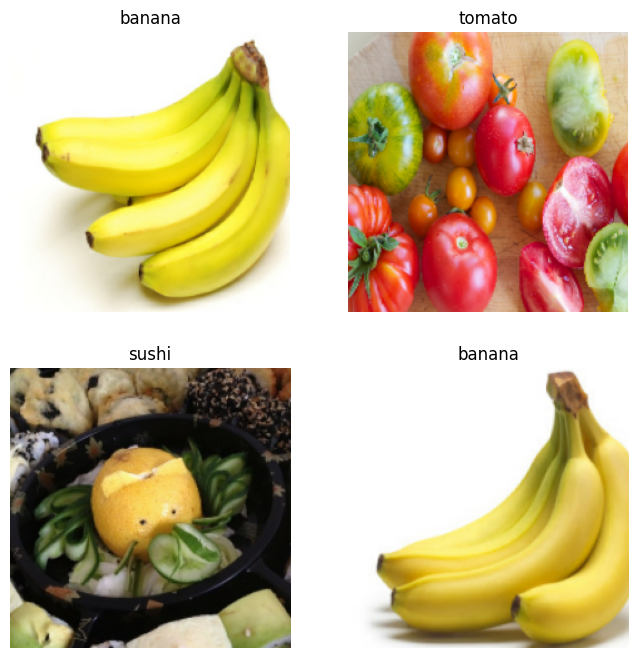

In [254]:
# affiche un batch d'images

def imshow(images, labels=None):
    images = images.numpy()

    means = np.array([103.939, 116.779, 123.68])
    images = images + means

    images = images[..., ::-1]

    images = np.clip(images, 0, 255).astype(np.uint8)

    plt.figure(figsize=(8, 8))
    for i in range(len(images)):
        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
        if labels is not None:
            plt.title(class_names[labels[i]])

    plt.show()

images, labels = next(iter(train_ds))
imshow(images, np.nonzero(labels)[1])

## Fonction de prédiction sur un batch

In [255]:
# prédit la classe sur un batch de validation et affiche les résultats

def predict(model):
    images, labels = next(iter(val_ds))
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)
    imshow(images, preds)

## Fonction d'entraînement


In [268]:
# fonction d'entraînement d'un modèle avec sauvegarde du meilleur checkpoint

def train1(model, num_epochs=25, plot_learning_curve=False):
    # Définition du tracker impact environemental
    OUTPUT_DIR = "./metrics_models"
    EMI_FILE = "emissions.csv"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # tracking_mode="machine" pour mesurer tout le système (CPU + GPU)
    tracker = EmissionsTracker(
        project_name="Models_Benchmark",
        output_dir=OUTPUT_DIR,
        output_file=EMI_FILE,
        measure_power_secs=1,       # Mesure chaque seconde
        tracking_mode="machine",    
        log_level="error",          # Moins de bruit dans les logs
    )
    start = time.time()
    tracker.start()

    checkpoint_path = "best_model.keras"

    checkpoint_cb = keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True)

    lr_scheduler = keras.callbacks.LearningRateScheduler(lambda epoch: 0.001 * (0.1 ** (epoch // 7)))

    early_stopping_cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    history = model.fit(train_ds, validation_data=val_ds, epochs=num_epochs, callbacks=[checkpoint_cb, lr_scheduler, early_stopping_cb])

    model.load_weights(checkpoint_path)

    end = time.time()
    duration = end-start
    emissions_data = tracker.stop()

    # Lecture du fichier CSV généré pour extraire les valeurs précises
    df_carbon = pd.read_csv(f"{OUTPUT_DIR}/{EMI_FILE}")
    last_run = df_carbon.iloc[-1]

    print("-"*60)
    print(f"   Durée de la tâche    : {duration:.2f} secondes")
    print(f"   Localisation : {tracker._geo.country_name} ({tracker._geo.region})")
    print(f"   Énergie consommée    : {energy_wh:.6f} Wh")
    print(f"   Émissions CO2        : {emissions_g:.6f} g CO2eq")
    print("-"*60)

    if plot_learning_curve:
        plt.title("Learning curve")
        plt.plot(history.history["accuracy"], label="accuracy")
        plt.plot(history.history["val_accuracy"], label="val_accuracy")
        plt.legend()
        plt.xlabel(r"$n_{epochs}$")
    return model

## Expériences d'entraînement

### Implémentation de la baseline

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.6207 - f1_score: 0.6053 - loss: 0.9592 - val_accuracy: 0.5467 - val_f1_score: 0.5083 - val_loss: 1.2161 - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7759 - f1_score: 0.7906 - loss: 0.5511 - val_accuracy: 0.7333 - val_f1_score: 0.7393 - val_loss: 0.6664 - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8534 - f1_score: 0.8690 - loss: 0.4028 - val_accuracy: 0.7867 - val_f1_score: 0.8106 - val_loss: 0.5860 - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8664 - f1_score: 0.8734 - loss: 0.3307 - val_accuracy: 0.8400 - val_f1_score: 0.8525 - val_loss: 0.4366 - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8966 - f1_score: 0.9139 - loss: 0.3145 - val_accuracy: 0.9333 - val_f1_score: 0.9355 - val_loss: 0.3632 - learning_rate: 0.0010
Epoch 6/25
58/58 ━━━━━━━━━━━━━━━━━━

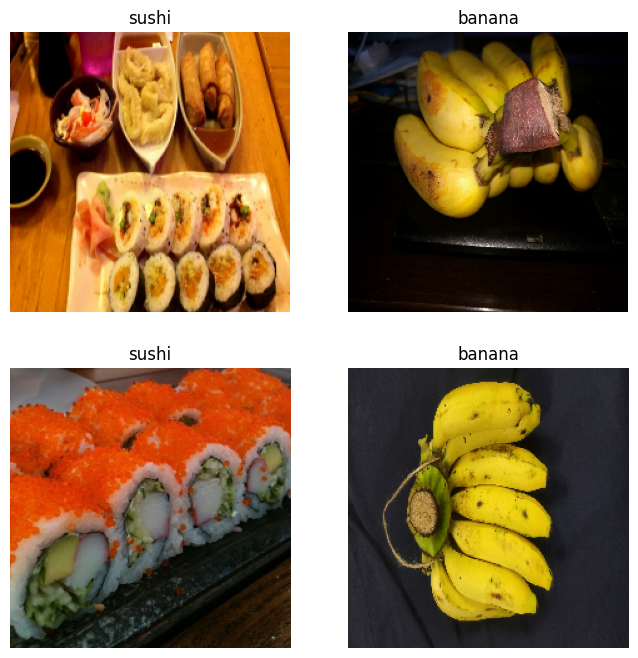

In [269]:
# utilisation du modèle léger MobileNet pré-entraîné comme extracteur de features, puis on ajoute une tête de classification adaptée au nombre de classes

base_model = MobileNet(weights="imagenet", include_top=False, input_shape=(224, 224, 3), alpha=.25, classes=num_classes)

x = layers.GlobalAveragePooling2D()(base_model.output)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

baseline = keras.Model(inputs=base_model.input, outputs=outputs)

baseline.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


baseline = train1(baseline, num_epochs=25)

predict(baseline)

### Implémentation de PMC

On commence par utiliser le perceptron multi-couches du 1er TP:

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.2026 - f1_score: 0.0346 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 6/25
58/58 ━━━━━━━━━━━━

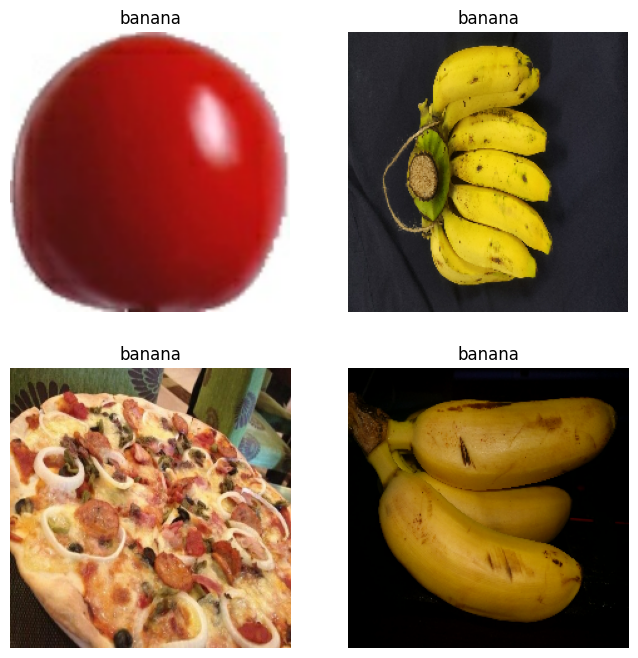

In [258]:
# Nombre de neurones sur les deux couches cachées
num_hidden_1 = 256
num_hidden_2 = 256

pcm1 = Sequential([
    Flatten(),
    Dense(units=num_hidden_1, activation='relu'),
    Dense(units=num_hidden_2, activation='relu'),
    Dense(units=num_classes, activation='softmax')
])

pcm1.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


pcm1 = train1(pcm1, num_epochs=25)

predict(pcm1)

In [259]:
question = f"""{CONTEXT}. Implement only a Multi-Layer Perceptron using sequential without import data and libraries because I already implemented them."""
rep_rag, sources = Tutor_python_rag(question, vectorstore, stream=True)

Great! You've come to me for help with implementing a deep learning model to classify images of pizza, tomato, banana, and sushi using a Multi-Layer Perceptron (MLP) in TensorFlow without importing any data or libraries. Here's a step-by-step guide on how to do it:

1. Importing the necessary modules:
```python
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
```
2. Defining the input shape and number of classes:
```python
image_height = 28 # Image height
image_width = 28 # Image width
num_classes = 4 # Number of classes (pizza, tomato, banana, sushi)
```
3. Creating a Sequential model:
```python
model = keras.Sequential()
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(num_classes, activation='softmax'))
```
In this example, we're using a Sequential model with three layers:

* Flatten(): This layer flattens the input image into a 1D array.
* Dense(): These are the dense layers that perform the ac

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.2500 - f1_score: 0.1990 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 6/25
58/58 ━━━━━━━━━━━━

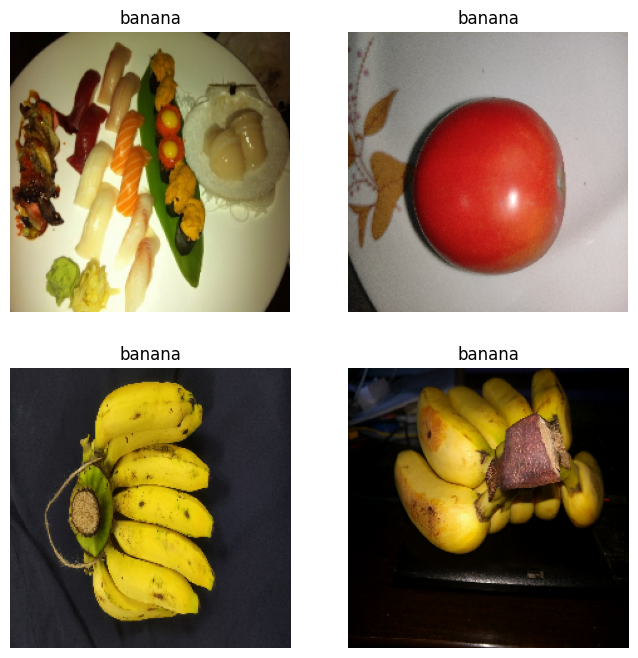

In [260]:
# Nombre de neurones sur les deux couches cachées
num_hidden_1 = 64

pcm2 = Sequential([
    Flatten(),
    Dense(units=num_hidden_1, activation='relu'),
    Dense(units=num_classes, activation='softmax')
])

pcm2.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


pcm2 = train1(pcm2, num_epochs=25)

predict(pcm2)

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.2112 - f1_score: 0.0798 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 6/25
58/58 ━━━━━━━

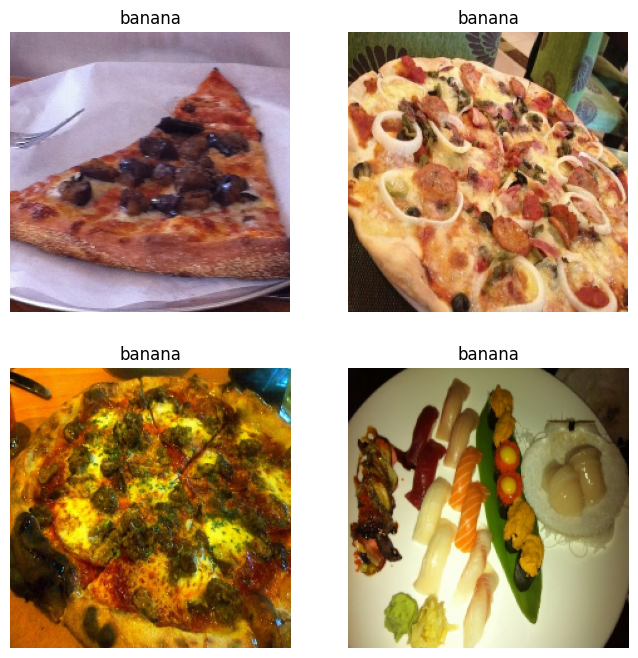

In [261]:
# Nombre de neurones sur les deux couches cachées
num_hidden_1 = 512
num_hidden_2 = 512

pcm3 = Sequential([
    Flatten(),
    Dense(units=num_hidden_1, activation='relu'),
    Dense(units=num_hidden_2, activation='relu'),
    Dense(units=num_classes, activation='softmax')
])

pcm3.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


pcm3 = train1(pcm3, num_epochs=25)
predict(pcm3)

In [262]:
pcm3.summary()

Model: "sequential_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_67 (Flatten)            │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_166 (Dense)               │ (None, 512)            │    77,070,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_167 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_168 (Dense)               │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,671,114 (590.02 MB)

 Trainable params: 77,335,556 (295.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 77,335,558 (295.01 MB)

On constate ici que les résulatats obtenus avec les PCM sont très mauvais comparé à la baseline, ce qui était prévisible dans la mesure où ce n'est pas le type d'architecture adapté à ce problème qui considère l'indépendance entre chaque pixel. On observe que le score F1 est nul est que la prédiciton pour le petit échantillon donne la même étiquette pour toutes images. Alors on se tourne maintenant vers un autre type de réseaux, les réseaux de convolutions (CNN) qui viennent palier ce problème par des filtres de convolution.

### Implémentation de CNN

On utilise la structure de CNN du 3e TP:

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 285ms/step - accuracy: 0.2716 - f1_score: 0.1860 - loss: 8404567.0000 - val_accuracy: 0.3200 - val_f1_score: 0.1212 - val_loss: 1.3723 - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 272ms/step - accuracy: 0.2802 - f1_score: 0.1616 - loss: 1.3772 - val_accuracy: 0.4133 - val_f1_score: 0.1462 - val_loss: 1.3545 - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 250ms/step - accuracy: 0.2974 - f1_score: 0.1162 - loss: 1.3694 - val_accuracy: 0.3200 - val_f1_score: 0.1212 - val_loss: 1.3452 - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 260ms/step - accuracy: 0.2888 - f1_score: 0.1770 - loss: 1.3652 - val_accuracy: 0.3200 - val_f1_score: 0.1212 - val_loss: 1.3379 - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 268ms/step - accuracy: 0.3060 - f1_score: 0.1228 - loss: 1.3621 - val_accuracy: 0.3200 - val_f1_score: 0.1212 - val_loss: 1.3313 - learning_rate: 0.0010
Epoch 6/25
58/58 ━━

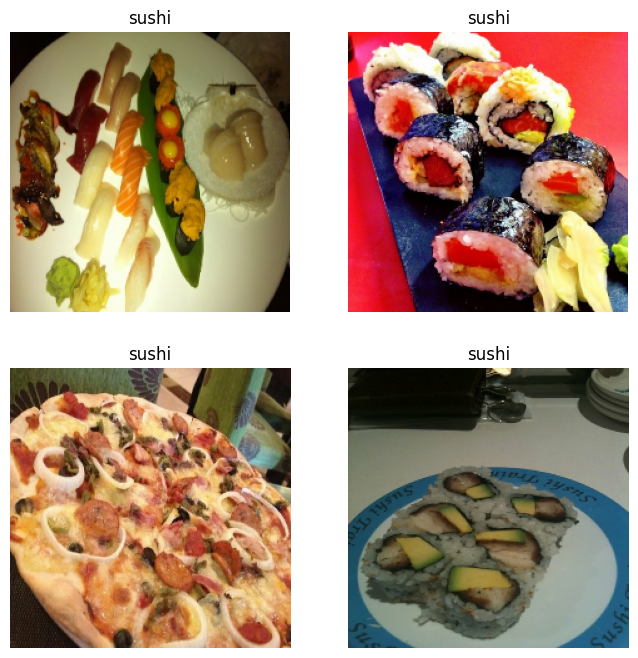

In [264]:
# Create a sequential model
cnn1 = Sequential([
    Input(shape=img_size+(3,)),
    Conv2D(filters=32, kernel_size=5, activation="relu", name="Conv1"),
    MaxPooling2D(pool_size=(2), name="MaxPooling2D"),
    Conv2D(filters=64, kernel_size=5, activation="relu", name="Conv2"),
    MaxPooling2D(pool_size=2, name="MaxPool2"),
    Flatten(),
    Dense(units=1024, name="Dense1", activation="relu"),
    Dropout(rate=0.20),
    Dense(units=num_classes, activation="softmax", name="output")])

cnn1.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


cnn1 = train1(cnn1, num_epochs=25)
predict(cnn1)

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.1897 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 6/25
58/58 ━━━

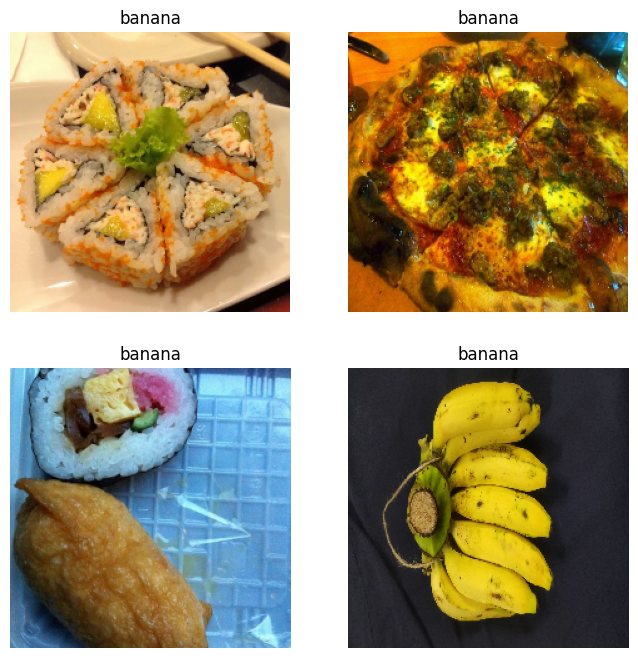

In [265]:
# network parameters
input_shape = img_size+(3,)
kernel_size = 3
strides     = 2
padding     = 'same'

extra_params_2dconv = {
    "kernel_size" : kernel_size,
    "strides"     : strides,
    "padding"     : padding,
    "activation"  : 'relu'
}

# Create a sequential model
cnn2 = Sequential([
    Input(shape=input_shape),
    Conv2D(
        filters=64,
        name="conv2d_22",
        **extra_params_2dconv
        ),
    Conv2D(
        filters=128, 
        name="conv2d_23",
        **extra_params_2dconv
        ),
    Conv2D(
        filters=256,
        name="conv2d_24",
        **extra_params_2dconv
        ),
    Flatten(),
    Dense(units=256, activation="relu"),
    Dense(units=num_classes, activation="relu")])

cnn2.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


cnn2 = train1(cnn2, num_epochs=25)
predict(cnn2)

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 15s 248ms/step - accuracy: 0.1940 - f1_score: 0.0815 - loss: 12.9953 - val_accuracy: 0.1333 - val_f1_score: 0.0588 - val_loss: 13.9690 - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 285ms/step - accuracy: 0.1940 - f1_score: 0.0812 - loss: 12.9917 - val_accuracy: 0.1333 - val_f1_score: 0.0588 - val_loss: 13.9690 - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 300ms/step - accuracy: 0.1940 - f1_score: 0.0812 - loss: 12.9917 - val_accuracy: 0.1333 - val_f1_score: 0.0588 - val_loss: 13.9690 - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 17s 296ms/step - accuracy: 0.1940 - f1_score: 0.0812 - loss: 12.9917 - val_accuracy: 0.1333 - val_f1_score: 0.0588 - val_loss: 13.9690 - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 348ms/step - accuracy: 0.1940 - f1_score: 0.0812 - loss: 12.9917 - val_accuracy: 0.1333 - val_f1_score: 0.0588 - val_loss: 13.9690 - learning_rate: 0.0010
Epoch 6/25
58/5

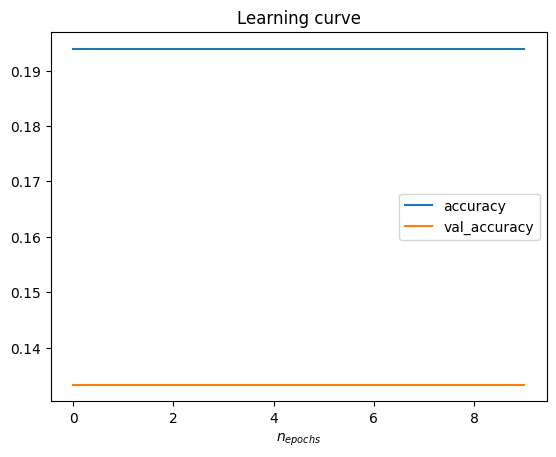

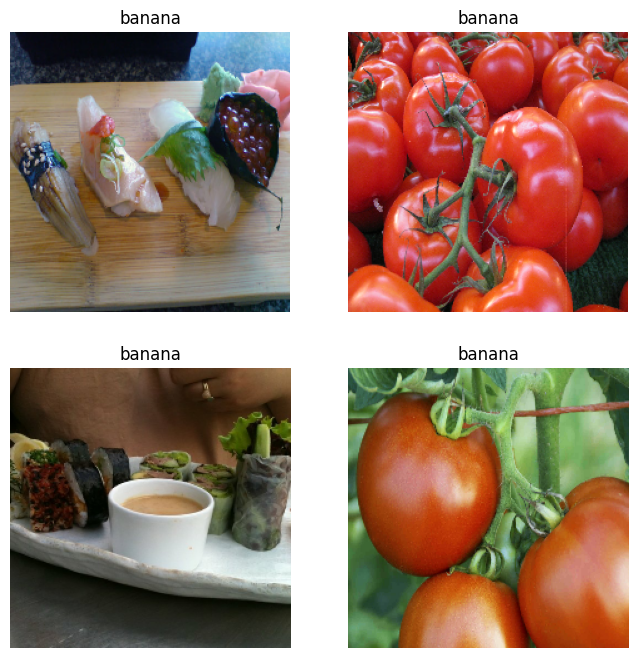

In [270]:
# network parameters
input_shape = img_size+(3,)
kernel_size = 6
strides     = 2
padding     = 'same'

extra_params_2dconv = {
    "kernel_size" : kernel_size,
    "strides"     : strides,
    "padding"     : padding,
    "activation"  : 'relu'
}

# Create a sequential model
cnn3 = Sequential([
    Input(shape=input_shape),
    Conv2D(
        filters=64,
        name="conv2d_22",
        **extra_params_2dconv
        ),
    Conv2D(
        filters=128, 
        name="conv2d_23",
        **extra_params_2dconv
        ),
    Conv2D(
        filters=256,
        name="conv2d_24",
        **extra_params_2dconv
        ),
    Flatten(),
    Dense(units=256, activation="relu"),
    Dense(units=num_classes, activation="relu")])

cnn3.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


cnn3 = train1(cnn3, num_epochs=25, plot_learning_curve=True)
predict(cnn3)

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.1940 - f1_score: 0.0064 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.1940 - f1_score: 0.0000e+00 - loss: nan - val_accuracy: 0.1333 - val_f1_score: 0.0000e+00 - val_loss: nan - learning_rate: 0.0010
Epoch 6/25
58/58 ━━━━━━

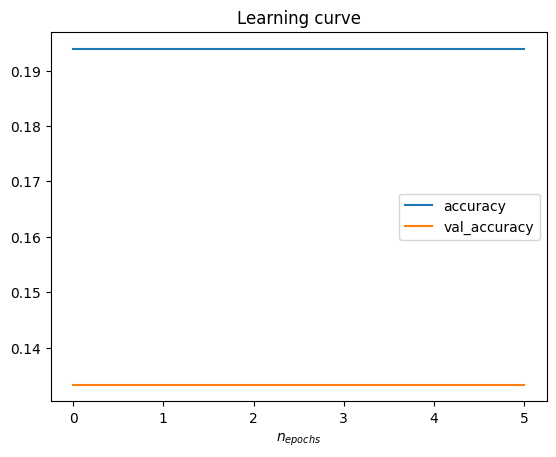

In [271]:
# network parameters
input_shape = img_size+(3,)
kernel_size = 3
strides     = 2
padding     = 'valid'

extra_params_2dconv = {
    "kernel_size" : kernel_size,
    "strides"     : strides,
    "padding"     : padding,
    "activation"  : 'relu'
}

# Create a sequential model
cnn3 = Sequential([
    Input(shape=input_shape),
    Conv2D(
        filters=64,
        name="conv2d_22",
        **extra_params_2dconv
        ),
    Conv2D(
        filters=128, 
        name="conv2d_23",
        **extra_params_2dconv
        ),
    Conv2D(
        filters=256,
        name="conv2d_24",
        **extra_params_2dconv
        ),
    Flatten(),
    Dense(units=256, activation="relu"),
    Dense(units=num_classes, activation="relu")])

cnn3.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


cnn3 = train1(cnn3, num_epochs=25, plot_learning_curve=True)

In [272]:
cnn3.summary()

Model: "sequential_89"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 111, 111, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 55, 55, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_74 (Flatten)            │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_178 (Dense)               │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_179 (Dense)               │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,295,690 (367.34 MB)

 Trainable params: 48,147,844 (183.67 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 48,147,846 (183.67 MB)

On constate qu'on obtient de meilleurs résultats que pour le PMC, mais restent insatisfaisants vis-à-vis de la baseline. Notamment on a la même observation pour le score F1 que pour le perceptron multi-couches. Alors on se tourne vers des modèles performants qui ont été développés par la communauté scientifique. Ils sont disponibles en lignes et pré-entrainés. Cette méthode s'appelle le *transfer learning*. Les modèles existants se distinguent par leur niveau de performance en termes de précision et de taille.

## Transfer Learning

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 38s 546ms/step - accuracy: 0.6207 - f1_score: 0.6364 - loss: 0.8740 - val_accuracy: 0.7733 - val_f1_score: 0.7444 - val_loss: 0.5533 - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 31s 540ms/step - accuracy: 0.8491 - f1_score: 0.8521 - loss: 0.3990 - val_accuracy: 0.9067 - val_f1_score: 0.9074 - val_loss: 0.2926 - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 33s 572ms/step - accuracy: 0.8836 - f1_score: 0.8895 - loss: 0.3508 - val_accuracy: 0.8800 - val_f1_score: 0.8718 - val_loss: 0.3899 - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 33s 569ms/step - accuracy: 0.8836 - f1_score: 0.8836 - loss: 0.3298 - val_accuracy: 0.9067 - val_f1_score: 0.9132 - val_loss: 0.3489 - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 32s 559ms/step - accuracy: 0.9397 - f1_score: 0.9387 - loss: 0.2054 - val_accuracy: 0.8533 - val_f1_score: 0.8488 - val_loss: 0.4356 - learning_rate: 0.0010
Epoch 6/25
58/58 ━━━━━━━━

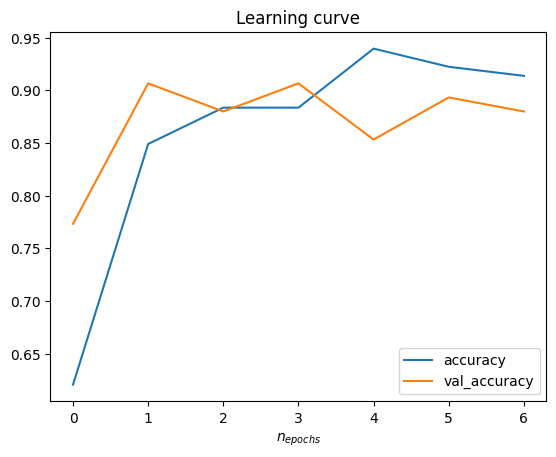

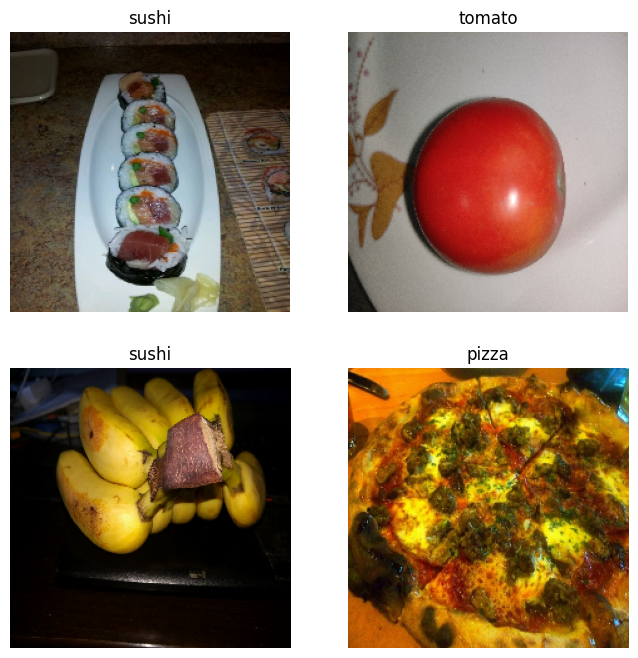

In [273]:
from keras.applications import ResNet50V2 
base_model = ResNet50V2(weights="imagenet", include_top=False, input_shape=(224, 224, 3), classes=num_classes)

x = layers.GlobalAveragePooling2D()(base_model.output)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

resnet = keras.Model(inputs=base_model.input, outputs=outputs)

resnet.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


resnet = train1(resnet, num_epochs=25, plot_learning_curve=True)

predict(resnet)

In [274]:
resnet.summary()

Model: "functional_107"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_111     │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_111[… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 47,100,554 (179.67 MB)

 Trainable params: 23,527,556 (89.75 MB)

 Non-trainable params: 45,440 (177.50 KB)

 Optimizer params: 23,527,558 (89.75 MB)

Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.4138 - f1_score: 0.4108 - loss: 1.4065 - val_accuracy: 0.1733 - val_f1_score: 0.1421 - val_loss: 22.2677 - learning_rate: 0.0010
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.6897 - f1_score: 0.7128 - loss: 0.6923 - val_accuracy: 0.2000 - val_f1_score: 0.1917 - val_loss: 5.0826 - learning_rate: 0.0010
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.8060 - f1_score: 0.8279 - loss: 0.4899 - val_accuracy: 0.1733 - val_f1_score: 0.1761 - val_loss: 4.4151 - learning_rate: 0.0010
Epoch 4/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.7974 - f1_score: 0.8179 - loss: 0.5063 - val_accuracy: 0.1867 - val_f1_score: 0.1711 - val_loss: 4.3416 - learning_rate: 0.0010
Epoch 5/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.8190 - f1_score: 0.8268 - loss: 0.5316 - val_accuracy: 0.1867 - val_f1_score: 0.1760 - val_loss: 4.7064 - learning_rate: 0.0010
Epoch 6/25
58/58 ━━━━━━━━━━━━━━━━

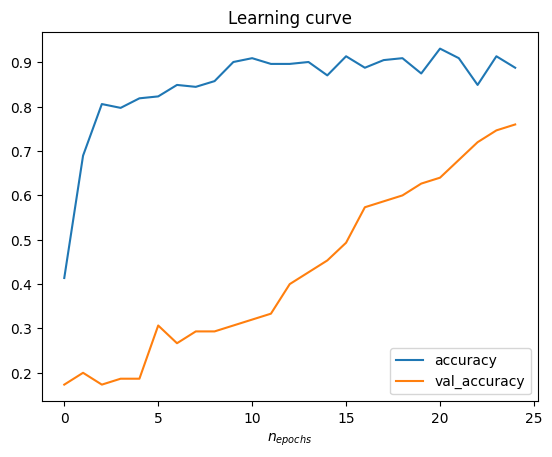

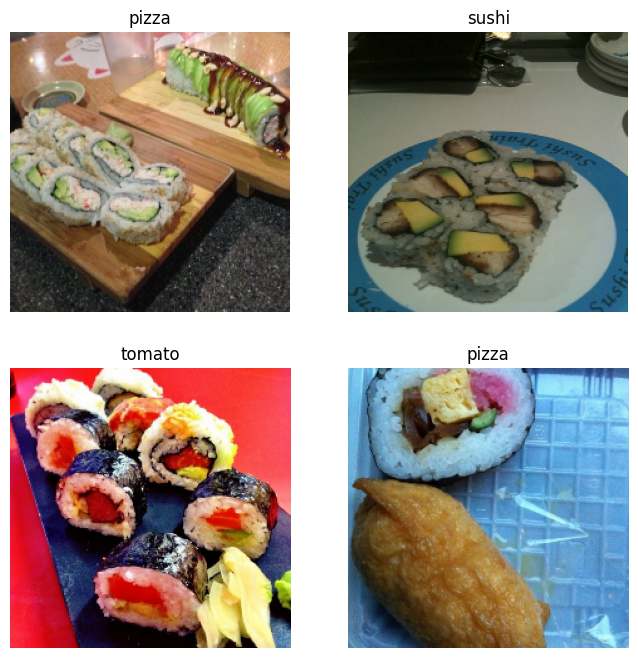

In [275]:
from keras.applications import MobileNetV3Small
base_model = MobileNetV3Small(weights="imagenet", include_top=False, input_shape=(224, 224, 3), classes=num_classes, alpha=0.75)

x = layers.GlobalAveragePooling2D()(base_model.output)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

mnv3s = keras.Model(inputs=base_model.input, outputs=outputs)

mnv3s.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


mnv3s = train1(mnv3s, num_epochs=25, plot_learning_curve=True)

predict(mnv3s)

On constate que la courbe de validation est encore en train de croitre, le modèle est encore en train d'apprendre. On ajoute des époques.

Epoch 1/35
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.5647 - f1_score: 0.5791 - loss: 1.0922 - val_accuracy: 0.5333 - val_f1_score: 0.5281 - val_loss: 1.2845 - learning_rate: 0.0010
Epoch 2/35
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8190 - f1_score: 0.8362 - loss: 0.4286 - val_accuracy: 0.6800 - val_f1_score: 0.6802 - val_loss: 0.8629 - learning_rate: 0.0010
Epoch 3/35
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8750 - f1_score: 0.8845 - loss: 0.3545 - val_accuracy: 0.7333 - val_f1_score: 0.7290 - val_loss: 0.6379 - learning_rate: 0.0010
Epoch 4/35
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.8836 - f1_score: 0.8901 - loss: 0.3126 - val_accuracy: 0.8533 - val_f1_score: 0.8346 - val_loss: 0.4209 - learning_rate: 0.0010
Epoch 5/35
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.8922 - f1_score: 0.9003 - loss: 0.3140 - val_accuracy: 0.8800 - val_f1_score: 0.8738 - val_loss: 0.3585 - learning_rate: 0.0010
Epoch 6/35
58/58 ━━━━━━━━━━━━━━━━━━

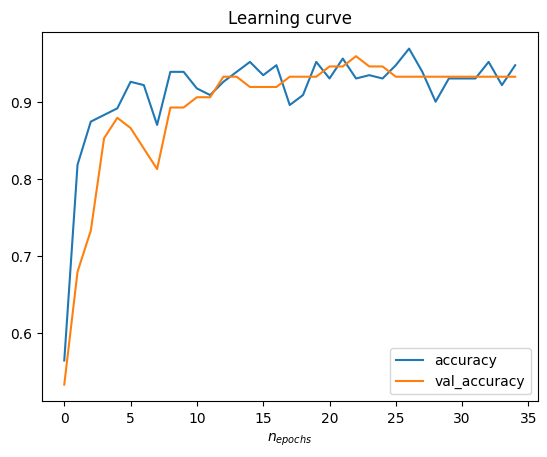

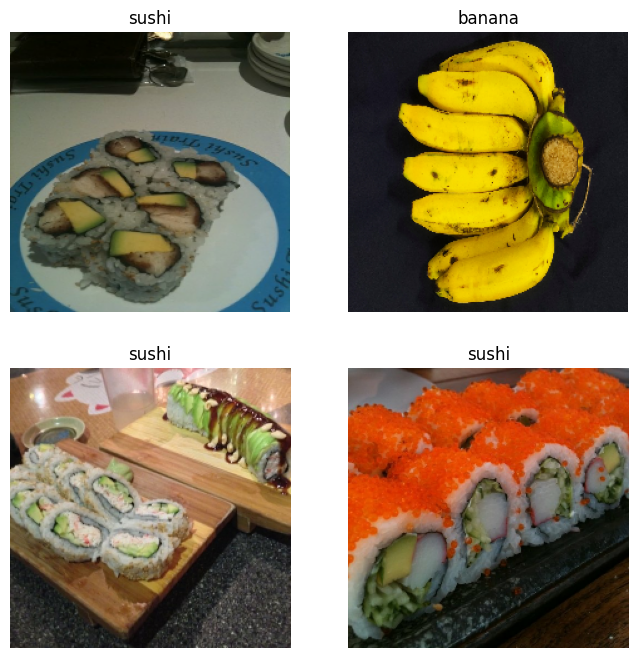

In [278]:
from keras.applications import MobileNetV3Small
base_model = MobileNetV3Small(weights="imagenet", include_top=False, input_shape=(224, 224, 3), classes=num_classes, alpha=0.75)

x = layers.GlobalAveragePooling2D()(base_model.output)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

mnv3s = keras.Model(inputs=base_model.input, outputs=outputs)

mnv3s.compile(
    optimizer=optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.metrics.F1Score(average="macro")]
)


mnv3s = train1(mnv3s, num_epochs=35, plot_learning_curve=True)

predict(mnv3s)

In [276]:
mnv3s.summary()

Model: "functional_108"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_112     │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_112[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_2[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation_36[0]… │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_28 (ReLU)     │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu_28[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_29 (ReLU)     │ (None, 1, 1, 16)  │          0 │ add_18[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_18         │ (None, 1, 1, 16)  │          0 │ re_lu_29[0][0]    │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu_28[0][0],   │
│ (Multiply)          │ 16)               │            │ multiply_18[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,160,106 (4.43 MB)

 Trainable params: 575,212 (2.19 MB)

 Non-trainable params: 9,680 (37.81 KB)

 Optimizer params: 575,214 (2.19 MB)

On constate à travers ces derniers modèles que les modèles déjà existants sont bien plus performants que ce qu'on a pu faire avec des petits modèles naïfs de PMC et CNN et qu'ils permettent de dépasser les performances de la baseline. On constate que l'entraînement a toujours approximativement la même empreinte carbone. En revanche, de part leur taille en terme de paramètre, elle peut augmenter lors du déploiement.(180MB pour Resnet et 4MB pour MobileNetV3Small) Il s'agit donc d'une balance à trouver. 

**Ici il s'avère que le modèle que le modèle le plus performant (MobileNetV3Small) est également le plus léger. Donc c'est celui que l'on retient pour ce projet.**


Concernant l'agent IA, il donnait des résultats plutôt satisfaisant mais pas suffisamment pour qu'il puisse nous rendre plus productif. En effet, l'agent, bien qu'on lui demande de ne pas réimporter les librairies et un jeu de données, il s'obstinait à le faire ce qui rendait le temps de réponse plus lent encore. Enfin les signatures de fonctions proposées étaient parfois inexactes et il n'était pas en mesure à nous apporter des solutions aux erreurs.